# Tutorial 6: Temporal Questions — Lag, Precision, and Transfer Entropy

The tutorials so far have asked a single question: *how much* information
do X and Y share? This is fundamental, but it is only the beginning of what
MI-based analysis can reveal about neural circuits.

Real neuroscience data has temporal structure. Signals travel between brain
regions with measurable delays. Neurons encode stimuli with varying degrees
of timing precision. Information flows in specific directions — a sensory
area drives a motor area, not the other way around. None of these properties
are captured by a single MI number.

This tutorial introduces three analysis modes that probe the temporal
structure of information:

- **`mode='lag'`**: sweeps a range of time offsets between X and Y and
  finds the delay at which MI is maximised. This is the transmission delay
  of the circuit.
- **`mode='precision'`**: progressively corrupts spike timing and measures
  when MI degrades. The timescale at which MI drops to 90% of its baseline
  is the *precision timescale* — how accurately spike times must be
  preserved to maintain the information they carry.
- **`mode='transfer'`**: computes transfer entropy TE(X→Y) and TE(Y→X),
  asking whether X's past predicts Y's future above and beyond Y's own past,
  and vice versa. Asymmetry in these two values is evidence of directed
  information flow.

We use a single synthetic dataset throughout: two populations of spike trains
where Y fires with a known 20 ms delay after X. This gives us ground truth
for all three analyses.

## 1. Setup: Paired Spike Populations with a Known Delay

We generate two spike populations using
`nmi.generators.generate_correlated_spike_trains`.
Population X is a Poisson process; population Y fires with a 20 ms delay
and 5 ms timing jitter after each corresponding spike in X.
Both populations have 10 neurons firing at 5 Hz over a 100-second recording.

At 5 Hz over 100 seconds, each neuron fires approximately 500 spikes —
giving us a rich dataset for all three analyses.

The data is passed to the library as `List[np.ndarray]` (one array of
spike timestamps per neuron), using `Processing(x='spike')`.
Because this is a continuous recording, we use `Split(mode='blocked')`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)

# Known ground truth parameters
true_delay_s   = 0.02   # 20 ms delay from X to Y
true_jitter_s  = 0.005  # 5 ms timing jitter in Y

pop_x, pop_y = nmi.generators.generate_correlated_spike_trains(
    n_neurons=10,
    duration=100.0,
    firing_rate=5.0,
    delay=true_delay_s,
    jitter=true_jitter_s
)

print(f"Population X: {len(pop_x)} neurons")
print(f"Population Y: {len(pop_y)} neurons")
print(f"Example — Neuron 0, first 5 spike times in X: "
      f"{np.round(pop_x[0][:5], 4)} s")
print(f"Example — Neuron 0, first 5 spike times in Y: "
      f"{np.round(pop_y[0][:5], 4)} s")
print(f"\nKnown delay X → Y: {true_delay_s*1000:.0f} ms")
print(f"Known jitter in Y: {true_jitter_s*1000:.0f} ms")

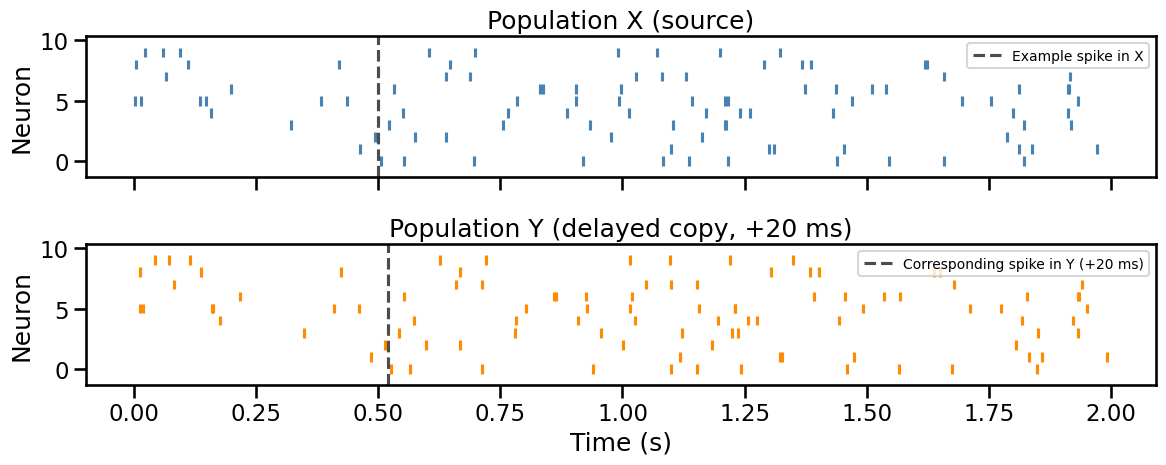

In [2]:
# Raster plot: first 2 seconds of both populations
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# Top panel: Population X
spikes_x_2s = [s[s < 2.0] for s in pop_x]
ax_top.eventplot(spikes_x_2s, color='steelblue', lineoffsets=range(len(pop_x)),
                 linelengths=0.8)
ax_top.axvline(x=0.5, color='black', linestyle='--', alpha=0.7,
               label='Example spike in X')
ax_top.set_title("Population X (source)")
ax_top.set_ylabel("Neuron")
ax_top.legend(fontsize=10, loc='upper right')

# Bottom panel: Population Y (delayed copy)
spikes_y_2s = [s[s < 2.0] for s in pop_y]
ax_bot.eventplot(spikes_y_2s, color='darkorange', lineoffsets=range(len(pop_y)),
                 linelengths=0.8)
ax_bot.axvline(x=0.5 + true_delay_s, color='black', linestyle='--', alpha=0.7,
               label=f'Corresponding spike in Y (+20 ms)')
ax_bot.set_title("Population Y (delayed copy, +20 ms)")
ax_bot.set_xlabel("Time (s)")
ax_bot.set_ylabel("Neuron")
ax_bot.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

## 2. Lag Analysis: Finding the Transmission Delay

The simplest temporal question: is there a delay between X and Y, and if so,
how large is it?

`mode='lag'` sweeps a range of time offsets, shifting Y relative to X by
each offset in turn, estimating MI at each shift, and returning the full
tuning curve. The peak of this curve is the estimated transmission delay.

We test lags from $-50$ ms to $+80$ ms in steps of 5 ms. We expect a sharp
peak at $+20$ ms — the delay we injected into the data.

**Note on lag units for spike data:** for spike input (`Processing(x='spike')`),
timestamps are always in seconds, so `Lag(lag_range=...)` is specified in seconds.
The library shifts Y spike times by subtracting each lag value directly.
The `lag` column in the results dataframe is therefore also in seconds;
multiply by 1000 to convert to milliseconds for plotting.

In [ ]:
model = nmi.Model(hidden_dim=64, embedding_dim=32, n_layers=2)
training = nmi.Training(n_epochs=100, patience=25)

window_size_s = 0.05  # 50 ms windows for spike binning

# Lag range in seconds: -50 ms to +80 ms in 5 ms steps
# For spike data, lag_range is always in seconds — no sample_rate conversion needed
lag_range_s = np.arange(-0.05, 0.085, 0.005)  # -50 ms to +80 ms in 5 ms steps

print(f"Testing {len(lag_range_s)} lags from "
      f"{lag_range_s[0]*1000:.0f} ms to {lag_range_s[-1]*1000:.0f} ms...")

lag_results = nmi.run(
    pop_x, pop_y,
    mode='lag',
    lag=nmi.Lag(lag_range=lag_range_s),               # seconds for spike data
    processing=nmi.Processing(x='spike', x_params={'window_size': window_size_s},
                              y='spike', y_params={'window_size': window_size_s}),
    split=nmi.Split(mode='blocked'),    # CORRECT: continuous recording
    model=model, training=training,
    n_workers=4,
    show_progress=False,
)

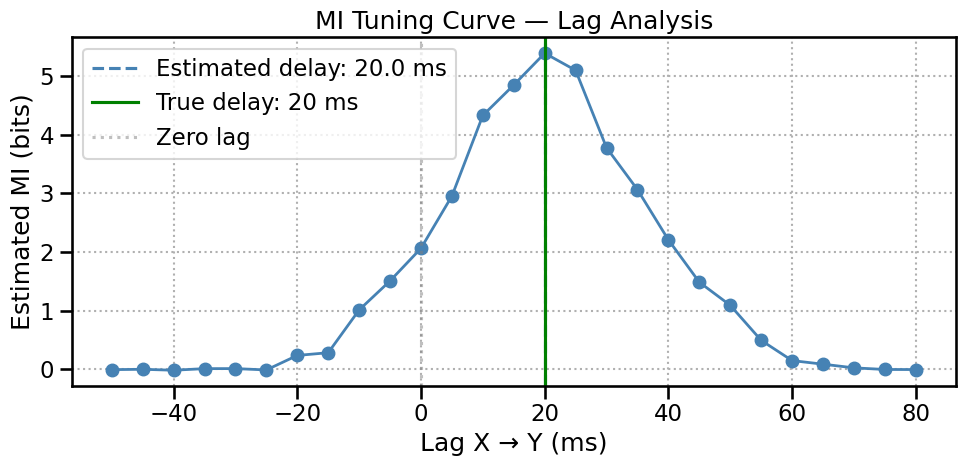


Estimated delay: 20.0 ms
True delay:      20 ms


In [4]:
df_lag = lag_results.dataframe

# Lag dataframe columns after aggregation across runs:
# 'lag'     — the lag value in seconds (same units as lag_range)
# 'mi_mean' — mean MI estimate across runs at this lag
# 'mi_std'  — standard deviation across runs at this lag
lag_col = 'lag'
mi_col  = 'mi_mean'

# Convert lag to milliseconds for plotting
lags_ms = df_lag[lag_col] * 1000

plt.figure(figsize=(10, 5))
plt.plot(lags_ms, df_lag[mi_col], 'o-', color='steelblue', linewidth=2)

# Mark the peak
peak_idx    = df_lag[mi_col].idxmax()
peak_lag_ms = lags_ms[peak_idx]
peak_mi     = df_lag[mi_col][peak_idx]
plt.axvline(x=peak_lag_ms, color='steelblue', linestyle='--',
            label=f'Estimated delay: {peak_lag_ms:.1f} ms')
plt.axvline(x=true_delay_s * 1000, color='green', linestyle='-',
            label=f'True delay: {true_delay_s*1000:.0f} ms')
plt.axvline(x=0, color='grey', linestyle=':', alpha=0.5, label='Zero lag')

plt.title("MI Tuning Curve — Lag Analysis")
plt.xlabel("Lag X → Y (ms)")
plt.ylabel("Estimated MI (bits)")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

print(f"\nEstimated delay: {peak_lag_ms:.1f} ms")
print(f"True delay:      {true_delay_s*1000:.0f} ms")

The tuning curve should peak close to the true 20 ms delay, with MI dropping
off on either side. At zero lag, MI is lower because X and Y are misaligned
— the spike pattern in Y that corresponds to a given X pattern has not
arrived yet. At negative lags (Y shifted before X), MI is near zero because
Y cannot predict X's future.

The width of the peak reflects the jitter in the data: with 5 ms jitter in Y,
the MI curve is broad around the true delay rather than a sharp spike.

This analysis is directly applicable to real data: if you record simultaneously
from two brain regions, the lag at which MI is maximised is the transmission
delay of the circuit connecting them. Note, however, that a lag analysis
identifies a correlational delay — it does not by itself establish the
direction of causation. For that, we need transfer entropy (Section 4).

### 2b. Jointly Sweeping Lag and Window Size

The lag analysis above fixed the window size at 50 ms and swept only the lag.
In practice the two choices interact: too short a window may not capture
enough correlated activity to estimate MI reliably, while too long a window
blurs the temporal precision of the lag estimate. Sweeping both together and
visualising the result as a heatmap makes this trade-off directly visible.

`mode='lag'` already sweeps `lag_range` internally; we sweep `window_size`
ourselves in a loop and stack the resulting per-window dataframes into one —
giving a combined table with `lag`, `window_size`, and `mi_mean` columns.
`nmi.visualize.analyze_mi_heatmap` consumes exactly that shape: it locates the
region of the (lag, window_size) plane where MI is significant and draws a
"parsimonious circle" around the smallest window size on the boundary of that
region — the most temporally precise setting that still detects the coupling.

In [ ]:
window_size_grid_s = [0.02, 0.05, 0.08, 0.11]        # 20, 50, 80, 110 ms
lag_range_heatmap_s = np.arange(-0.02, 0.06, 0.01)   # -20 ms to +50 ms in 10 ms steps

print(f"Sweeping {len(lag_range_heatmap_s)} lags × {len(window_size_grid_s)} window sizes "
      f"= {len(lag_range_heatmap_s) * len(window_size_grid_s)} tasks...")

# mode='lag' sweeps lag_range internally; window_size is not one of the
# parameters its own sweep_grid routes to the processor, so we sweep it
# ourselves and stack the per-window results into one long dataframe —
# exactly the ('lag', 'window_size', 'mi_mean') shape analyze_mi_heatmap needs.
heatmap_rows = []
for w in window_size_grid_s:
    r_w = nmi.run(
        pop_x, pop_y,
        mode='lag',
        lag=nmi.Lag(lag_range=lag_range_heatmap_s),
        processing=nmi.Processing(x='spike', x_params={'window_size': w},
                                  y='spike', y_params={'window_size': w}),
        split=nmi.Split(mode='blocked'),    # CORRECT: continuous recording
        model=model, training=training,
        n_workers=4,
        show_progress=False,
    )
    sub = r_w.dataframe[['lag', 'mi_mean']].copy()
    sub['window_size'] = w
    heatmap_rows.append(sub)

df_heatmap = pd.concat(heatmap_rows, ignore_index=True)
df_heatmap[['lag', 'window_size', 'mi_mean']].head()

In [ ]:
ax = nmi.visualize.analyze_mi_heatmap(
    df_heatmap,
    true_lag=true_delay_s,
    history_duration=true_jitter_s,  # closest proxy available — see note below
    show=False,
)
plt.tight_layout()
plt.show()

The heatmap shows estimated MI as a function of lag (x-axis) and window size
(y-axis). The red **Significant MI Contour** outlines the region where MI
exceeds `absolute_mi_threshold`; the cyan **Causal Contour** (traced from the
MI rise at lag = 0) marks where `lag + window_size` is approximately
constant — the geometric signature of a fixed-latency dependency smeared out
by the analysis window. The white **Parsimonious Circle** sits at the
smallest window size on the boundary of the significant region: the most
temporally precise setting that still reliably detects the coupling.

The green box marks the injected ground truth. We used the generation jitter
as a stand-in for "history duration" since our generator produces a single
delayed, jittered spike per input spike rather than a windowed history
dependency — `analyze_mi_heatmap`'s causal-contour geometry is built for the
more general case where Y depends on a *window* of X's recent past. Our
point-delay example is a degenerate case of that, useful mainly to show the
API; on data with genuine history-dependence (e.g. synaptic integration over
tens of milliseconds) the causal contour and parsimonious circle carry more
information than they do here.

For real recordings, where you know neither the true delay nor the relevant
integration window, this heatmap is the practical way to choose both at once
rather than guessing a window size and only sweeping lag.

## 3. Precision Analysis: Rate Code vs. Timing Code

Knowing that spike population X is informative about Y is useful.
But neuroscientists often want to know *how* that information is encoded:
is it in the precise millisecond-level timing of individual spikes, or only
in the coarser firing rate averaged over tens of milliseconds?

`mode='precision'` answers this by progressively **corrupting the data**
and measuring when MI degrades.  The **precision timescale** $\tau^*$ is the
corruption level at which MI drops to 90% of its clean baseline.

- A **small** $\tau^*$ means the code is **precise**: even a little added
  noise destroys the information.
- **No** $\tau^*$ found at all means the code is **robust**: information
  survives because it lives in coarser features — the firing rate per window,
  not the exact timing of each individual spike.

We demonstrate both outcomes: first with our spike data (rate-coded circuit),
then with correlated continuous signals (amplitude-coded, giving a clear
precision curve).

### 3a. Spike Data: Rate-Coded Information

Our spike data uses 50 ms analysis windows.  After binning, the network
learns to predict Y's **spike count per window** from X's — a *rate code*.
Within-window jitter changes individual spike times but leaves the count
unchanged, so the network's inputs are unaffected and MI stays constant.

**A flat MI curve is not a failure** — it tells us that the information in
this circuit is carried by firing *rate*, not by the precise timing of
individual spikes.  We therefore expect $\tau^*$ to be undefined.

In [ ]:
# tau_grid in seconds — matching spike time units
tau_grid = [0.0, 0.001, 0.002, 0.005, 0.010, 0.020, 0.050]
# 0 ms, 1 ms, 2 ms, 5 ms, 10 ms, 20 ms, 50 ms

print("Running precision analysis on spike data (rate-coded)...")
print(f"Jitter levels: {[t*1000 for t in tau_grid]} ms")
print(f"Corruption: 'noise' (uniform jitter added to X spike times)")
print(f"Threshold: MI drops to 90% of baseline\n")

# corrupt_target options:
#   'x'    — jitter X only (default; isolates X timing precision)
#   'y'    — jitter Y only
#   'both' — jitter X and Y simultaneously (measures *shared* timing precision)
precision_results = nmi.run(
    pop_x, pop_y,
    mode='precision',
    precision=nmi.Precision(tau_grid=tau_grid,
                            corrupt_target='x',          # jitter X spike times only
                            corruption_method='noise',   # uniform jitter
                            threshold_ratio=0.9),
    processing=nmi.Processing(x='spike', x_params={'window_size': window_size_s},
                              y='spike', y_params={'window_size': window_size_s}),
    split=nmi.Split(mode='blocked'),        # CORRECT: continuous recording
    model=model, training=training,
    n_workers=4,
    show_progress=False,
)

In [9]:
baseline_mi   = precision_results.details['baseline_mi']
precision_tau = precision_results.details['precision_tau']  # np.nan if not found
threshold_val = precision_results.details['threshold_value']

print(f"Baseline MI (τ=0):  {baseline_mi:.3f} bits")
print(f"MI threshold (90%): {threshold_val:.3f} bits")
if not np.isnan(precision_tau):
    print(f"Precision τ*:       {precision_tau*1000:.1f} ms")
    print(f"\nInterpretation: spike timing in X must be accurate to within "
          f"{precision_tau*1000:.1f} ms to preserve 90% of the information.")
else:
    print(f"Precision τ*:       not found — MI is flat across all jitter levels.")
    print(f"\nInterpretation: the information is rate-coded. MI does not depend "
          f"on the precise timing of individual spikes within each 50 ms window.")

Baseline MI (τ=0):  2.292 bits
MI threshold (90%): 2.063 bits
Precision τ*:       not found — MI is flat across all jitter levels.

Interpretation: the information is rate-coded. MI does not depend on the precise timing of individual spikes within each 50 ms window.


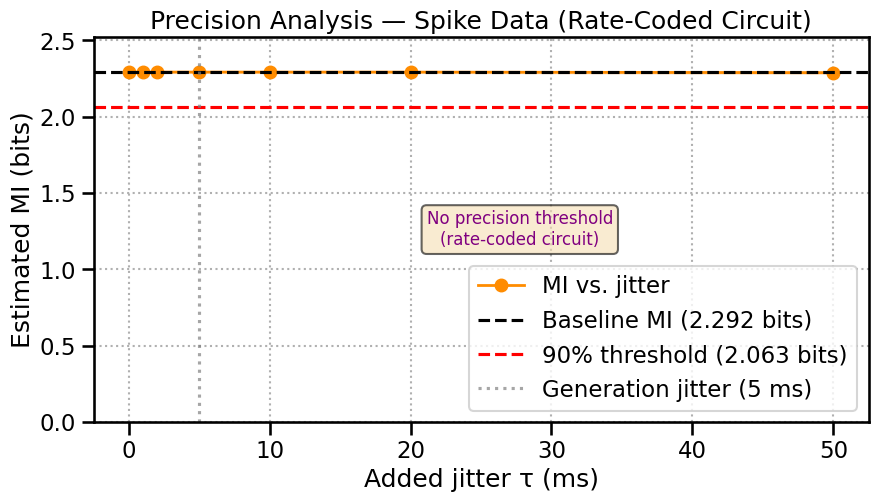

In [10]:
df_prec = precision_results.dataframe
tau_ms  = df_prec['tau'] * 1000   # convert to milliseconds for plotting

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tau_ms, df_prec['train_mi'], 'o-', color='darkorange', linewidth=2,
        label='MI vs. jitter')

if 'train_mi_std' in df_prec.columns:
    ax.fill_between(tau_ms,
                    df_prec['train_mi'] - df_prec['train_mi_std'],
                    df_prec['train_mi'] + df_prec['train_mi_std'],
                    color='darkorange', alpha=0.2)

ax.axhline(y=baseline_mi, color='black', linestyle='--',
           label=f'Baseline MI ({baseline_mi:.3f} bits)')
ax.axhline(y=threshold_val, color='red', linestyle='--',
           label=f'90% threshold ({threshold_val:.3f} bits)')

if not np.isnan(precision_tau):
    ax.axvline(x=precision_tau * 1000, color='purple', linestyle='-',
               label=f'τ* = {precision_tau*1000:.1f} ms')
else:
    ax.text(0.55, 0.50, 'No precision threshold\n(rate-coded circuit)',
            transform=ax.transAxes, ha='center', va='center', fontsize=12,
            color='purple', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

ax.axvline(x=true_jitter_s * 1000, color='grey', linestyle=':',
           alpha=0.7, label=f'Generation jitter ({true_jitter_s*1000:.0f} ms)')

ax.set_title("Precision Analysis — Spike Data (Rate-Coded Circuit)")
ax.set_xlabel("Added jitter τ (ms)")
ax.set_ylabel("Estimated MI (bits)")
ax.legend()
ax.grid(True, linestyle=':')
ax.set_ylim(0, baseline_mi * 1.1)
plt.show()

The flat MI curve is the expected result for a rate-coded circuit.
Adding jitter to spike times within each 50 ms window does not change the
spike *count* in that window, so the model's effective input is unchanged
and MI stays constant across all tested $\tau$ values.

This is a scientifically meaningful result: the information in this circuit
is carried by firing rate, not by precise spike timing.  A timing-coded
circuit would show a sharp decline in MI at small jitter values.

### 3b. Continuous Signals: Amplitude-Coded Information

To see what a precision-sensitive MI curve looks like, we switch to
correlated continuous signals where the *amplitude* of the signal carries
information.  Corrupting the amplitude with additive noise directly degrades
the information, producing a clear precision curve.

We generate two correlated Gaussian signals with $\rho = 0.9$ and sweep
noise levels in units of signal standard deviation ($\sigma \approx 1$).
The precision threshold $\tau^*$ is where MI drops to 90% of baseline —
roughly the noise level at which the signal-to-noise ratio starts to hurt.

**Data format note:** We pass raw 1D arrays (shape `(n_samples,)`) without
a processor type.  `StaticDataset` auto-reshapes them to `(n_samples, 1, 1)`,
treating each sample as an independent observation.  The `tau_grid` is
therefore in the same units as the signal values — signal standard deviations.

In [11]:
np.random.seed(42)
n_cont = 5000
rho    = 0.9

# Correlated Gaussian signals — 1D arrays, StaticDataset reshapes to (N, 1, 1)
x_cont = np.random.randn(n_cont)
y_cont = rho * x_cont + np.sqrt(1 - rho**2) * np.random.randn(n_cont)

print(f"Continuous data: {n_cont} i.i.d. samples,  ρ = {rho}")
print(f"Signal std:  X = {x_cont.std():.3f},  Y = {y_cont.std():.3f}")
print(f"Empirical correlation: {np.corrcoef(x_cont, y_cont)[0, 1]:.3f}  (expected {rho})")
print(f"\nTheoretical MI = −½ log(1 − ρ²) "
      f"= {-0.5*np.log(1-rho**2):.3f} nats "
      f"= {-0.5*np.log(1-rho**2)/np.log(2):.3f} bits")

Continuous data: 5000 i.i.d. samples,  ρ = 0.9
Signal std:  X = 0.996,  Y = 0.998
Empirical correlation: 0.897  (expected 0.9)

Theoretical MI = −½ log(1 − ρ²) = 0.830 nats = 1.198 bits


In [12]:
# tau_grid in signal std units (std ≈ 1)
# 'noise' corruption draws Uniform(−τ/2, +τ/2); std_noise = τ / sqrt(12) ≈ 0.29 τ
tau_grid_cont = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

print("Running precision analysis on continuous correlated signals...")
print(f"τ values (signal std units): {tau_grid_cont}")
print(f"Threshold: MI drops to 90% of baseline\n")

prec_cont = nmi.run(
    x_cont, y_cont,
    mode='precision',
    precision=nmi.Precision(tau_grid=tau_grid_cont,
                            corrupt_target='x',
                            corruption_method='noise',
                            threshold_ratio=0.9),
    # No processing — StaticDataset treats each sample as an i.i.d. observation
    split=nmi.Split(mode='random'),           # i.i.d. samples — random train/test split is correct
    model=model, training=nmi.Training(n_epochs=100, patience=15),
    seed=42,
    show_progress=False,
)

2026-03-05 11:33:52 - neural_mi - WARNING - Custom train_indices and test_indices were provided. The split_mode, train_fraction, n_test_blocks, and split_gap_fraction parameters will be ignored for this run.


Running precision analysis on continuous correlated signals...
τ values (signal std units): [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
Threshold: MI drops to 90% of baseline



Run :   0%|          | 0/100 [00:00<?, ?it/s]

In [13]:
bl_cont  = prec_cont.details['baseline_mi']
tau_star = prec_cont.details['precision_tau']
thr_cont = prec_cont.details['threshold_value']

print(f"Baseline MI (τ=0):  {bl_cont:.3f} bits")
print(f"MI threshold (90%): {thr_cont:.3f} bits")
if not np.isnan(tau_star):
    print(f"Precision τ*:       {tau_star:.2f} σ")
    print(f"\nInterpretation: noise larger than τ* = {tau_star:.2f} σ "
          f"degrades the information by more than 10%.")
else:
    print("Precision τ*: not found — MI remains above threshold for all tested τ.")
    print("Consider extending tau_grid to larger values.")

Baseline MI (τ=0):  1.183 bits
MI threshold (90%): 1.064 bits
Precision τ*:       1.00 σ

Interpretation: noise larger than τ* = 1.00 σ degrades the information by more than 10%.


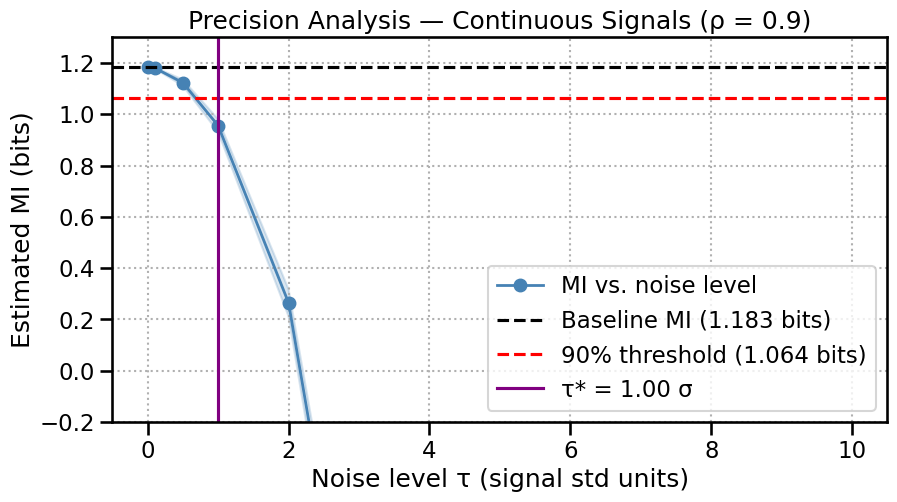

In [16]:
df_cont = prec_cont.dataframe

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_cont['tau'], df_cont['train_mi'], 'o-', color='steelblue', linewidth=2,
        label='MI vs. noise level')

if 'train_mi_std' in df_cont.columns:
    ax.fill_between(df_cont['tau'],
                    df_cont['train_mi'] - df_cont['train_mi_std'],
                    df_cont['train_mi'] + df_cont['train_mi_std'],
                    color='steelblue', alpha=0.2)

ax.axhline(y=bl_cont,  color='black', linestyle='--',
           label=f'Baseline MI ({bl_cont:.3f} bits)')
ax.axhline(y=thr_cont, color='red',   linestyle='--',
           label=f'90% threshold ({thr_cont:.3f} bits)')

if not np.isnan(tau_star):
    ax.axvline(x=tau_star, color='purple', linestyle='-',
               label=f'τ* = {tau_star:.2f} σ')

ax.set_title("Precision Analysis — Continuous Signals (ρ = 0.9)")
ax.set_xlabel("Noise level τ (signal std units)")
ax.set_ylabel("Estimated MI (bits)")
ax.legend()
ax.grid(True, linestyle=':')
ax.set_ylim(-0.2, bl_cont * 1.1)
plt.show()

The MI curve falls smoothly as $\tau$ increases, crossing the 90% threshold
at $\tau^*$ — the noise level at which signal-to-noise degradation begins to
cost a meaningful fraction of the information.

Comparing the two scenarios:

| Scenario | Signal | Precision curve | $\tau^*$ |
|---------|--------|----------------|---------|
| Spike population (3a) | Spike count per 50 ms window | Flat — no degradation | Undefined |
| Correlated Gaussians (3b) | Signal amplitude ($\sigma \approx 1$) | Smooth decline | $\approx$ 0.5–2 $\sigma$ |

In practice, neural circuits often use a mixture of rate and timing codes.
Precision analysis reveals which regime a circuit operates in:
if MI is flat across all jitter levels, the code is coarse (rate); if it
falls sharply, the code relies on fine-grained structure (timing or amplitude).

**Alternative corruption method:** `Precision(corruption_method='rounding')` rounds
each value to the nearest multiple of $\tau$ rather than adding noise.
This gives a sharper cutoff — information below $\tau$ is completely
destroyed, while information above $\tau$ is perfectly preserved.
Choose `'noise'` for a biologically realistic simulation and `'rounding'`
for a cleaner theoretical analysis.

## 4. Transfer Entropy: Directed Information Flow

The lag analysis in Section 2 showed that MI peaks at a 20 ms delay from
X to Y. But MI is symmetric: $I(X; Y) = I(Y; X)$. The lag curve told us
*when* the signals are most correlated, not *which one drives the other*.

Transfer entropy (TE) breaks this symmetry. It is defined as:

$$\text{TE}(X \to Y) = I(x_\text{past},\, y_\text{past};\, y_\text{future})
  - I(y_\text{past};\, y_\text{future})$$

In words: how much does knowing X's recent history improve our prediction of
Y's future, **above and beyond** what Y's own history already tells us?
If $\text{TE}(X \to Y) > 0$, X carries unique predictive information about
Y — evidence of directed influence from X to Y.

We compute both $\text{TE}(X \to Y)$ and $\text{TE}(Y \to X)$ and compare
them. In our dataset, X drives Y (Y is a delayed copy of X), so we expect
$\text{TE}(X \to Y) \gg \text{TE}(Y \to X)$.

**Important: data format for transfer entropy.** Unlike other modes, `mode='transfer'`
requires raw temporal data as a 2D array of shape `(n_timepoints, n_channels)`
— not pre-windowed data and not a spike time list. The library builds the
sliding history windows internally from `Transfer(history_window=...)`.
We therefore need to **bin our spike trains** into a count matrix before
passing them to transfer entropy mode.

We use a 10 ms bin size, giving a `(n_timebins, n_neurons)` matrix for
each population.

In [17]:
# Bin spike trains into count matrices for transfer entropy
# Transfer entropy requires (n_timepoints, n_channels) raw temporal data
bin_size_s   = 0.010   # 10 ms bins
duration_s   = 100.0
n_bins       = int(duration_s / bin_size_s)
bin_edges    = np.linspace(0, duration_s, n_bins + 1)

def bin_spike_trains(spike_list, bin_edges):
    """Bin a list of spike time arrays into a (n_bins, n_neurons) count matrix."""
    n_neurons = len(spike_list)
    n_bins_   = len(bin_edges) - 1
    counts    = np.zeros((n_bins_, n_neurons))
    for i, spikes in enumerate(spike_list):
        counts[:, i], _ = np.histogram(spikes, bins=bin_edges)
    return counts

x_binned = bin_spike_trains(pop_x, bin_edges)  # (n_bins, n_neurons)
y_binned = bin_spike_trains(pop_y, bin_edges)  # (n_bins, n_neurons)

print(f"Binned X shape: {x_binned.shape}  (n_timebins, n_neurons)")
print(f"Binned Y shape: {y_binned.shape}  (n_timebins, n_neurons)")
print(f"Bin size: {bin_size_s*1000:.0f} ms  |  "
      f"Total bins: {n_bins}  |  "
      f"Duration: {duration_s:.0f} s")

Binned X shape: (10000, 10)  (n_timebins, n_neurons)
Binned Y shape: (10000, 10)  (n_timebins, n_neurons)
Bin size: 10 ms  |  Total bins: 10000  |  Duration: 100 s


In [18]:
# history_window: number of past time bins to condition on
# At 10 ms bins, 5 bins = 50 ms of history — longer than the 20 ms delay
history_window = 5

print(f"History window: {history_window} bins = "
      f"{history_window * bin_size_s * 1000:.0f} ms\n")

print("Computing TE(X → Y)...")
te_x_to_y = nmi.run(
    x_binned, y_binned,
    mode='transfer',
    transfer=nmi.Transfer(history_window=history_window, prediction_horizon=1),
    split=nmi.Split(mode='blocked'),    # CORRECT: continuous recording
    model=model, training=training,
    n_workers=4,
    seed=42,
    show_progress=False,
)

print("Computing TE(Y → X)...")
te_y_to_x = nmi.run(
    y_binned, x_binned,   # note: x and y swapped to get TE(Y → X)
    mode='transfer',
    transfer=nmi.Transfer(history_window=history_window, prediction_horizon=1),
    split=nmi.Split(mode='blocked'),    # CORRECT: continuous recording
    model=model, training=training,
    n_workers=4,
    seed=42,
    show_progress=False,
)

print(f"\n--- Transfer Entropy Results ---")
print(f"TE(X → Y): {te_x_to_y.mi_estimate:.3f} bits  "
      f"(X drives Y — expect HIGH)")
print(f"TE(Y → X): {te_y_to_x.mi_estimate:.3f} bits  "
      f"(Y drives X — expect LOW)")
print(f"\nDirectionality ratio TE(X→Y) / TE(Y→X): "
      f"{te_x_to_y.mi_estimate / max(te_y_to_x.mi_estimate, 1e-6):.2f}")

2026-03-05 11:34:47 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


History window: 5 bins = 50 ms

Computing TE(X → Y)...


Parameter Sweep Progress:   0%|          | 0/1 [00:00<?, ?task/s]

2026-03-05 11:34:50 - neural_mi - INFO - Created PairedDataset


Parameter Sweep Progress:   0%|          | 0/1 [00:00<?, ?task/s]

...

Parameter Sweep Progress:   0%|          | 0/1 [00:00<?, ?task/s]

2026-03-05 11:35:15 - neural_mi - INFO - Created PairedDataset


Parameter Sweep Progress:   0%|          | 0/1 [00:00<?, ?task/s]

2026-03-05 11:35:24 - neural_mi - INFO - Created PairedDataset



--- Transfer Entropy Results ---
TE(X → Y): 1.770 bits  (X drives Y — expect HIGH)
TE(Y → X): 0.003 bits  (Y drives X — expect LOW)

Directionality ratio TE(X→Y) / TE(Y→X): 597.89


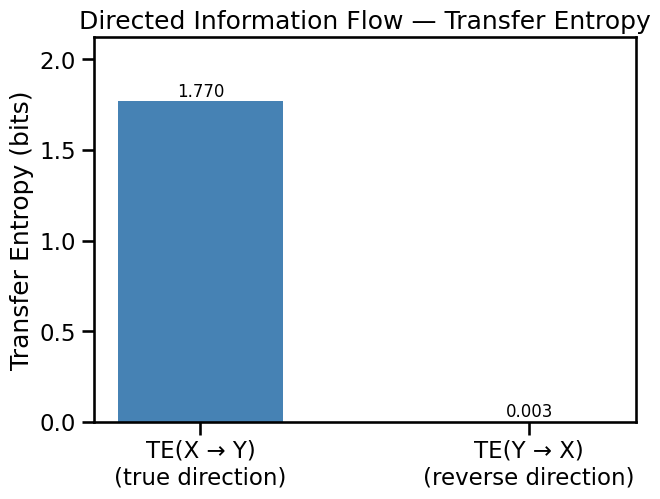

In [20]:
labels = ['TE(X → Y)\n(true direction)', 'TE(Y → X)\n(reverse direction)']
values = [te_x_to_y.mi_estimate, te_y_to_x.mi_estimate]
colors = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.5)
ax.set_ylabel("Transfer Entropy (bits)")
ax.set_title("Directed Information Flow — Transfer Entropy")
ax.set_ylim(bottom=0)

# Annotate bar values
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12)

plt.ylim(0, max(values) * 1.2)
plt.show()

The asymmetry between $\text{TE}(X \to Y)$ and $\text{TE}(Y \to X)$ confirms
the directed nature of the relationship: X's past is predictive of Y's future
(above and beyond Y's own past), but Y's past adds little to our prediction
of X's future. This matches the ground truth — Y is a delayed, noisy copy
of X, so information flows from X to Y, not in reverse.

In real data, neither direction will be exactly zero, and the asymmetry is
rarely as clean as in this synthetic example. A principled comparison requires
running `mode='rigorous'` on both directions and checking whether their
confidence intervals overlap. If $\text{TE}(X \to Y) - \text{TE}(Y \to X)$
is substantially larger than the combined uncertainty, it is evidence of
directed coupling.

**A note on interpretation:** Transfer entropy measures statistical
predictability, not physical causation. A strong $\text{TE}(X \to Y)$ means
X's past helps predict Y's future — this is consistent with X causing Y,
but also consistent with both X and Y being driven by a common upstream
source with different delays. Ruling out common causes requires additional
experimental or anatomical evidence.

## 5. Connecting the Three Analyses

The three analyses in this tutorial are not independent — they answer
complementary aspects of the same question about how information flows
between X and Y.

| Analysis | Question answered | Key result |
|---------|------------------|-----------|
| `mode='lag'` | When does Y know about X? | Peak MI at +20 ms delay |
| `mode='precision'` | Is information in spike timing or firing rate? | $\tau^*$ undefined: rate-coded circuit |
| `mode='transfer'` | Which direction does information flow? | TE(X→Y) ≫ TE(Y→X) |

Together, they tell a coherent story: X drives Y with a 20 ms delay; the
information is carried by the firing rate per 50 ms window, not by the
precise timing of individual spikes (the precision curve is flat);
and the influence is directional, from X to Y.

This is the kind of multi-layered characterisation that distinguishes a
thorough neural circuit analysis from a simple correlation measurement.

## 6. Key Takeaways

- **`mode='lag'`** sweeps temporal offsets between X and Y and returns an MI
  tuning curve. The peak offset is the estimated transmission delay. For spike
  data, `lag_range` is always specified in seconds (the native unit of spike
  timestamps); for continuous data, provide `sample_rate` in processor params
  to use seconds, or omit it to use integer sample offsets.

- **`mode='precision'`** corrupts data progressively and finds $\tau^*$,
  the level at which MI drops to `threshold_ratio` of its baseline.
  A **flat curve** — $\tau^*$ not found — is a valid result meaning the
  information is rate-coded (or otherwise robust to the type of corruption
  applied).  For spike data, `tau_grid` must be in seconds (matching spike
  timestamps).  For pre-processed continuous data, `tau_grid` is in signal
  units.  Use `Precision(corruption_method='noise')` for biological realism or
  `'rounding'` for a sharper, cleaner theoretical analysis.

- **`mode='transfer'`** requires raw binned data as `(n_timepoints, n_channels)`.
  Spike time lists must be binned first. Run both directions (X→Y and Y→X)
  and compare; asymmetry is evidence of directed coupling.

- **MI is symmetric; transfer entropy is not.** A lag analysis tells you when
  signals are correlated; transfer entropy tells you which one drives the other.
  Use both together for a complete characterisation.

- **Statistical significance requires rigorous mode.** For publication, run
  `mode='rigorous'` on each TE direction and confirm that their confidence
  intervals do not overlap before claiming directionality.

## Common Mistakes

1. **Passing spike time lists to `mode='transfer'`.** Transfer entropy requires
   `(n_timepoints, n_channels)` raw temporal data — not a list of spike timestamps.
   Bin your spike trains first (see the `bin_spike_trains` helper in Section 4)
   before passing them to this mode.

2. **Using too short a `history_window` for transfer entropy.** The history window
   must be longer than the transmission delay you are trying to detect. If the
   true delay is 20 ms and your bins are 10 ms, a history window of 1 bin (10 ms)
   will miss the delay entirely. Use a history window of at least 2–3× the
   expected delay.

3. **Specifying `tau_grid` in the wrong units for precision mode.** For spike
   data, timestamps are in seconds, so `tau_grid` must also be in seconds.
   For pre-processed continuous data (no processor type), `tau_grid` should
   be in signal units — the same units as the data values.  A mismatched
   `tau_grid` will produce a meaningless result without an error message.

4. **Interpreting a lag peak as causal direction.** The lag at which MI is
   maximised tells you the offset at which the two signals are most correlated
   — it does not tell you which one drives the other. Use transfer entropy for
   directional claims.

## What's Next

So far, every analysis has asked about the relationship *between* two signals.
In **Tutorial 7**, we turn to questions about the internal structure of a
single population: how many dimensions does a neural representation have?
What is the geometry of the information encoded by a population of neurons?
We introduce `mode='dimensionality'`, the pairwise MI matrix, and conditional
MI — and demonstrate all three on real neural data from the Allen Brain
Observatory and a hippocampal recording.